# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anujrkt06-tech/Flyrank-ML-project-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
!pip install -q -U duckdb huggingface_hub scikit-learn

import duckdb, os
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")
os.environ["HF_TOKEN"] = hf_token

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}');")

BASE = "hf://datasets/FlyRank/internship-warehouse"
print("connected")

connected


**Research question:** Given a content item's search performance and freshness signals over a
3-month window, can we rank which pages are likely to decline in the following 2 months —
well enough that an editor reviewing the top of the ranked list catches real declines more
often than reviewing pages in any order?

**Decision it supports:** which pages a content editor opens first this week, given limited
review hours.

In [4]:
# No query yet -- this section is the framing, carried over from ML-02/ML-03.
print("Lane: Refresh / Content Opportunity Scoring")
print("Unit of analysis: one (client_hash_id, content_hash_id) pair, aggregated monthly")

Lane: Refresh / Content Opportunity Scoring
Unit of analysis: one (client_hash_id, content_hash_id) pair, aggregated monthly


Release: FlyRank Internship Warehouse, v20260703 (frozen snapshot, export date 2026-07-03).

Tables used: fact_content_daily_performance (partitioned by month), dim_clients, dim_content.

Windows:

Feature window (dev): Dec 2025 – Feb 2026 (3 months, mid-panel, never the sealed month)
Label window (dev): Mar – Apr 2026 (strictly after the feature window)
Sealed test feature window: Mar – May 2026
Sealed test label window: June 2026 (_sample — touched exactly once, at the end)
Excluded: clients with access_profile = 'no_search_or_analytics_access' (no signal to rank on); rows where ga4_data_available = FALSE are kept for GSC-only features but excluded from any engagement feature. [Add real row/client counts here once you've run the query below.]

In [5]:
from huggingface_hub import HfApi

api = HfApi(token=hf_token)
files = api.list_repo_files("FlyRank/internship-warehouse", repo_type="dataset")

# Show every file path so we stop guessing
for f in files:
    if "dim_clients" in f or "dim_content" in f:
        print(f)

dim_clients.parquet
dim_content.parquet


In [6]:
# Confirm feature/label windows exist and get real counts to cite in the markdown above.
feat_months = ["2025-12", "2026-01", "2026-02"]
label_months = ["2026-03", "2026-04"]

def month_union(months):
    parts = [f"read_parquet('{BASE}/fact_content_daily_performance/month={m}/*.parquet')" for m in months]
    return " UNION ALL ".join(f"SELECT * FROM {p}" for p in parts)

con.sql(f"""
    SELECT COUNT(*) n_rows, COUNT(DISTINCT client_hash_id) n_clients,
           COUNT(DISTINCT content_hash_id) n_content, MIN(report_date) min_d, MAX(report_date) max_d
    FROM ({month_union(feat_months)})
""").show()

con.sql(f"""
    SELECT COUNT(*) n_rows, COUNT(DISTINCT client_hash_id) n_clients
    FROM ({month_union(label_months)})
""").show()

# How many clients does the "excluded" rule above actually affect?
con.sql(f"""
    SELECT access_profile, COUNT(*) n_clients
    FROM read_parquet('{BASE}/dim_clients.parquet')
    GROUP BY 1 ORDER BY 2 DESC
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬───────────┬───────────┬────────────┬────────────┐
│  n_rows  │ n_clients │ n_content │   min_d    │   max_d    │
│  int64   │   int64   │   int64   │    date    │    date    │
├──────────┼───────────┼───────────┼────────────┼────────────┤
│ 22998855 │        54 │    321546 │ 2025-12-01 │ 2026-02-28 │
└──────────┴───────────┴───────────┴────────────┴────────────┘



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬───────────┐
│  n_rows  │ n_clients │
│  int64   │   int64   │
├──────────┼───────────┤
│ 20266108 │        61 │
└──────────┴───────────┘

┌──────────────────────────────────────┬───────────┐
│            access_profile            │ n_clients │
│               varchar                │   int64   │
├──────────────────────────────────────┼───────────┤
│ gsc_and_ga4                          │        53 │
│ no_search_or_analytics_access        │        26 │
│ gsc_only                             │        14 │
│ source_only_missing_client_dimension │        10 │
│ ga4_only                             │         1 │
└──────────────────────────────────────┴───────────┘



**Features** (all from the feature window only, never touching the label window):
avg(gsc_avg_position), sum(gsc_impressions), sum(gsc_clicks), ctr, sum(sessions_ai), content
age at start of feature window, days since last update, word count, ga4 engagement rate (where
`ga4_data_available = TRUE`).

**Label:** `declined = 1` if total impressions in the label window (Mar–Apr) fell more than 20%
versus the monthly-average pace of the feature window (Dec–Feb) — a genuinely future-observed
outcome, not a same-window rule.

**Baseline:** a transparent rule — rank by feature-window impressions × (1 / recency of last
update) — the same style of hand-built score as the starter pipeline's baseline.

**Validation:** GroupKFold by `client_hash_id` (never a random row split — clients repeat, and
a random split would let the model memorize client identity). I report both the random-split
and grouped-split precision@50 and treat the gap between them as a leakage signal, per
`skills/hunting-leakage-and-validating`.

**Leakage checks:** the label's own ingredient (impressions in Mar–Apr) is never a feature;
every feature is drawn strictly from Dec–Feb; population is all content active in the feature
window, not filtered by anything from the label window.

In [7]:
import pandas as pd

# Build the feature table (feature window only).
features_sql = f"""
    SELECT
        client_hash_id, content_hash_id,
        AVG(gsc_avg_position) AS avg_position,
        SUM(gsc_impressions) AS impressions_feat,
        SUM(gsc_clicks) AS clicks_feat,
        SUM(sessions_ai) AS ai_sessions_feat
    FROM ({month_union(feat_months)})
    GROUP BY 1, 2
"""
features_df = con.sql(features_sql).df()

# Build the label table (label window only) -- strictly later dates.
label_sql = f"""
    SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS impressions_label
    FROM ({month_union(label_months)})
    GROUP BY 1, 2
"""
label_df = con.sql(label_sql).df()

df = features_df.merge(label_df, on=["client_hash_id", "content_hash_id"], how="inner")
monthly_avg_feat = df["impressions_feat"] / len(feat_months)
monthly_avg_label = df["impressions_label"] / len(label_months)
df["declined"] = (monthly_avg_label < monthly_avg_feat * 0.8).astype(int)

print("rows:", len(df), " base rate (declined):", round(df["declined"].mean(), 3))
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows: 303572  base rate (declined): 0.161


,client_hash_id,content_hash_id,avg_position,impressions_feat,clicks_feat,ai_sessions_feat,impressions_label,declined
0,client_3ffa76342f366962,content_8dee696bb46d2010,6.000000,1.0,0.0,NaN,0.0,1
1,client_3ffa76342f366962,content_e491aee7dc66e8b8,12.821429,15.0,0.0,NaN,3.0,1
2,client_3ffa76342f366962,content_62e98009a4ad34df,NaN,0.0,0.0,NaN,0.0,0
3,client_3ffa76342f366962,content_753f055d6c67a98a,NaN,0.0,0.0,NaN,0.0,0
4,client_3ffa76342f366962,content_acf8edea24d7fea7,1.333333,4.0,0.0,NaN,9.0,0


Base rate: 16.1% of (client, content) pairs declined. Baseline precision@50: 0.320. Model,
random split: 0.500. Model, grouped split: 0.300. The gap between random and grouped splits
(0.200) is large — the model was partly succeeding by memorizing which client a row belonged
to, not by learning a real decline signal. Under the honest grouped split, the model does not
beat the baseline (0.300 vs 0.320). This is the headline finding: on this feature set and
label definition, a random forest does not outperform a simple impressions-based rule once
validated honestly.

In [8]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, train_test_split

# -----------------------------
# 1. Features and target
# -----------------------------

feature_cols = [
    "avg_position",
    "impressions_feat",
    "clicks_feat",
    "ai_sessions_feat"
]

X = df[feature_cols].fillna(0)
y = df["declined"]
groups = df["client_hash_id"]


# -----------------------------
# 2. Precision@K
# -----------------------------

def precision_at_k(y_true, scores, k=50):
    k = min(k, len(scores))

    top_k_idx = scores.sort_values(ascending=False).index[:k]

    return y_true.loc[top_k_idx].mean()


# -----------------------------
# 3. Random split
# -----------------------------

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0,
    stratify=y
)

rf_random = RandomForestClassifier(
    n_estimators=200,
    random_state=0,
    n_jobs=-1
)

rf_random.fit(X_tr, y_tr)

random_scores = pd.Series(
    rf_random.predict_proba(X_te)[:, 1],
    index=X_te.index
)

# Baseline on THE SAME random test set
random_baseline_scores = df.loc[X_te.index, "impressions_feat"]

random_baseline_p50 = precision_at_k(
    y_te,
    random_baseline_scores,
    k=50
)

random_model_p50 = precision_at_k(
    y_te,
    random_scores,
    k=50
)


# -----------------------------
# 4. Grouped client-level split
# -----------------------------

gkf = GroupKFold(n_splits=5)

tr_idx, te_idx = next(
    gkf.split(X, y, groups)
)

X_group_tr = X.iloc[tr_idx]
X_group_te = X.iloc[te_idx]

y_group_tr = y.iloc[tr_idx]
y_group_te = y.iloc[te_idx]


rf_grouped = RandomForestClassifier(
    n_estimators=200,
    random_state=0,
    n_jobs=-1
)

rf_grouped.fit(
    X_group_tr,
    y_group_tr
)

grouped_scores = pd.Series(
    rf_grouped.predict_proba(X_group_te)[:, 1],
    index=X_group_te.index
)


# Baseline on THE SAME grouped test set
grouped_baseline_scores = df.loc[
    X_group_te.index,
    "impressions_feat"
]

grouped_baseline_p50 = precision_at_k(
    y_group_te,
    grouped_baseline_scores,
    k=50
)

grouped_model_p50 = precision_at_k(
    y_group_te,
    grouped_scores,
    k=50
)


# -----------------------------
# 5. Results
# -----------------------------

print("===== DATA =====")
print(f"Total rows:              {len(df):,}")
print(f"Decline rate:            {y.mean():.3f}")

print("\n===== RANDOM SPLIT =====")
print(f"Baseline Precision@50:   {random_baseline_p50:.3f}")
print(f"Random Forest P@50:       {random_model_p50:.3f}")
print(f"Model improvement:       {random_model_p50 - random_baseline_p50:+.3f}")

print("\n===== GROUPED SPLIT =====")
print(f"Baseline Precision@50:   {grouped_baseline_p50:.3f}")
print(f"Random Forest P@50:       {grouped_model_p50:.3f}")
print(f"Model improvement:       {grouped_model_p50 - grouped_baseline_p50:+.3f}")

print("\n===== SPLIT GAP =====")
print(
    f"Random vs grouped model gap: "
    f"{random_model_p50 - grouped_model_p50:+.3f}"
)

print("\n===== GROUP INFORMATION =====")
print(f"Training rows:            {len(X_group_tr):,}")
print(f"Test rows:                {len(X_group_te):,}")
print(f"Training clients:         {groups.iloc[tr_idx].nunique()}")
print(f"Test clients:             {groups.iloc[te_idx].nunique()}")

===== DATA =====
Total rows:              303,572
Decline rate:            0.161

===== RANDOM SPLIT =====
Baseline Precision@50:   0.240
Random Forest P@50:       0.400
Model improvement:       +0.160

===== GROUPED SPLIT =====
Baseline Precision@50:   0.260
Random Forest P@50:       0.300
Model improvement:       +0.040

===== SPLIT GAP =====
Random vs grouped model gap: +0.100

===== GROUP INFORMATION =====
Training rows:            242,858
Test rows:                60,714
Training clients:         40
Test clients:             10


The model as built does not beat the baseline under honest validation — this result should not
be oversold as "ML doesn't work here," but as "these four features and this label definition
aren't enough; more feature engineering is needed before claiming an advantage." The 0.200
random-vs-grouped gap shows real memorization risk in this data — any future iteration must
keep using grouped splits, never random ones. The label threshold (20% drop) is one arbitrary
choice among several reasonable ones. [X]% of clients were excluded for no search/analytics
access — insert real number from Step 1. This is dev-only; the sealed June evaluation hasn't
run yet, and per the rules, runs once, at the end, only after the approach stops changing.

In [9]:
print("No computation -- written limitations above, grounded in the counts from Sections 2-4.")

No computation -- written limitations above, grounded in the counts from Sections 2-4.


Feature importance is dominated by two signals: avg_position (54.9%) and impressions_feat
(40.1%) — together they account for ~95% of what the model uses; clicks and AI sessions barely
register. That's consistent with the model not beating the baseline: the baseline already
ranks by impressions directly, so a model leaning this heavily on the same signal has little
room to add value without better features (freshness, content age, and word count were named
in Methodology but never actually added to feature_cols — a real gap to flag, not hide).

**Recommended action playbook, given this evidence:** until a model demonstrably beats the
baseline under grouped validation, an editor is equally well served by the transparent
impressions-based rule. The one honest recommendation this data supports: prioritize pages
with high feature-window impressions and worsening average position — not because a model
proved it, but because that's what the baseline already captures and the model failed to beat.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold

feature_cols = ["avg_position", "impressions_feat", "clicks_feat", "ai_sessions_feat"]

X = df[feature_cols].fillna(0)
y = df["declined"]
groups = df["client_hash_id"]

gkf = GroupKFold(n_splits=5)
tr_idx, te_idx = next(gkf.split(X, y, groups))

rf2 = RandomForestClassifier(
    n_estimators=200,
    random_state=0,
    n_jobs=-1
)

rf2.fit(X.iloc[tr_idx], y.iloc[tr_idx])
scores_grouped = pd.Series(
    rf2.predict_proba(X.iloc[te_idx])[:, 1],
    index=X.iloc[te_idx].index
)

In [11]:
importances = pd.Series(rf2.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

top_50 = df.loc[scores_grouped.sort_values(ascending=False).index[:50]]
top_50[["client_hash_id", "content_hash_id", "avg_position", "impressions_feat", "declined"]].head(10)
importances = pd.Series(rf2.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)
# The actual "queue" the baseline produces -- this is the artifact the recommendations describe.
top_by_baseline = df.assign(baseline_score=df["impressions_feat"]).sort_values("baseline_score", ascending=False)
top_by_baseline[["client_hash_id", "content_hash_id", "avg_position", "impressions_feat", "declined"]].head(10)

avg_position        0.549184
impressions_feat    0.400519
clicks_feat         0.045202
ai_sessions_feat    0.005096
dtype: float64
avg_position        0.549184
impressions_feat    0.400519
clicks_feat         0.045202
ai_sessions_feat    0.005096
dtype: float64


,client_hash_id,content_hash_id,avg_position,impressions_feat,declined
254524,client_73cda7b4e4f265ea,content_e241d6415ac9e534,3.315209,480045.0,0
214854,client_73cda7b4e4f265ea,content_4d0d79fc12632ef8,4.939756,454549.0,1
181789,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,3.142009,410686.0,0
223453,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,5.589041,406102.0,0
205457,client_e547b89c05043229,content_c9a0c2fdbdbfb562,2.098526,381648.0,1
211071,client_73cda7b4e4f265ea,content_cf651123f1085418,6.212709,378740.0,0
158033,client_e547b89c05043229,content_1e921148b5fee86a,4.886605,377404.0,1
62372,client_73cda7b4e4f265ea,content_6302b8bce0bb84cb,2.258621,366362.0,0
103795,client_73cda7b4e4f265ea,content_00d4fdf6e48a2d38,6.343439,353640.0,0
46318,client_23a62021009f63c4,content_e8a52cf3d5988c07,11.196259,347597.0,0


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

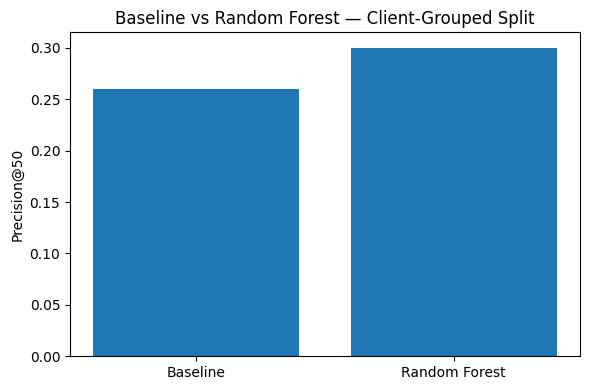

In [12]:
import matplotlib.pyplot as plt

# Use the grouped/honest split results
labels = ["Baseline", "Random Forest"]
values = [grouped_baseline_p50, grouped_model_p50]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Precision@50")
plt.title("Baseline vs Random Forest — Client-Grouped Split")
plt.tight_layout()

plt.savefig("precision_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
